In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("default")
plt.rcParams.update({"font.family": "serif", "font.serif": ["Times New Roman"]})

In [2]:
ENV_NAME = "k_out_of_n_infinite"
SETTINGS = [f"hard-{k}-of-4_infinite" for k in range(1, 5)]
SETTING_NAMES = [f"{k}-out-of-4" for k in range(1, 5)]

# SARSOP polices with large number of alpha vectors (SARSOP runtime: 6h)
SARSOP_experiments_large = {
    "hard-1-of-4_infinite": "l9bfLjPX",
    "hard-2-of-4_infinite": "34ypHTmE",
    "hard-3-of-4_infinite": "CdY0nHXL",
    "hard-4-of-4_infinite": "wzkWS4mv",
}

# 48h runtime
SARSOP_experiments_extra_large = {
    "hard-1-of-4_infinite": "Xumo56vJ",
    "hard-2-of-4_infinite": "f1XRFNih",
    "hard-3-of-4_infinite": "QyXUirzp",
    "hard-4-of-4_infinite": "pf5v4r7l",
}

ylimits = {
    "hard-1-of-4_infinite": (80, 30),
    "hard-2-of-4_infinite": (200, 100),
    "hard-3-of-4_infinite": (450, 200),
    "hard-4-of-4_infinite": (950, 600),
}

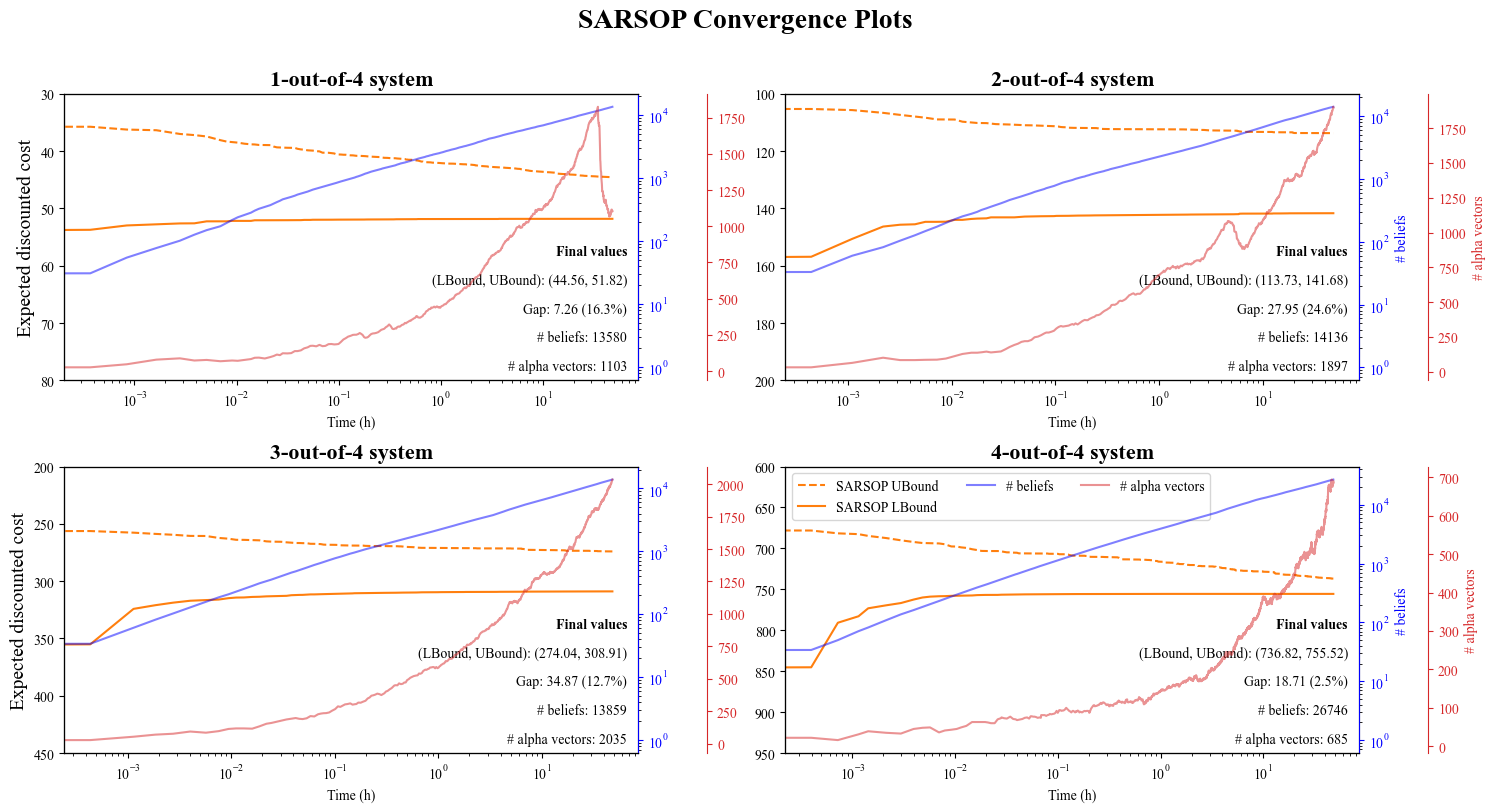

In [3]:
prefix_path = "../sarsop_baseline/SARSOP_models_and_policies"

fig, ax_ = plt.subplots(2, 2, figsize=(15, 8))

# columns = ["Time", "#Trial", "#Backup", "LBound", "UBound", "Precision", "#Alphas", "#Beliefs"]

c = 0
for env_name, sarsop_id in SARSOP_experiments_extra_large.items():

    i, j = c // 2, c % 2

    ax = ax_[i, j]

    with open(f"{prefix_path}/{env_name}/{sarsop_id}/convergence.log", "r") as f:
        lines = f.readlines()

    start = (
        lines.index(
            "-------------------------------------------------------------------------------\n"
        )
        + 3
    )
    table = " ".join(lines[start:])

    data = np.array(
        [
            list(map(float, line.split()))
            for line in table.split("\n")
            if len(line.split()) == 8
        ]
    )

    time_ = (data[:, 0] - data[0, 0]) / 3600

    # Plot the data
    ax.semilogx(
        time_, -data[:, 4], linestyle="--", label="SARSOP UBound", color="tab:orange"
    )
    ax.semilogx(time_, -data[:, 3], label="SARSOP LBound", color="tab:orange")

    ax_twin = ax.twinx()
    ax_twin.loglog(time_, data[:, -1], color="blue", label="# beliefs", alpha=0.5)
    ax_twin.spines["right"].set_color("blue")
    ax_twin.tick_params(axis="y", colors="blue")
    if c in [1, 3]:
        ax_twin.set_ylabel("# beliefs", color="blue")

    # another twin axis with offset of 1.15
    ax_twin2 = ax.twinx()
    ax_twin2.semilogx(
        time_, data[:, -2], color="tab:red", label="# alpha vectors", alpha=0.5
    )
    ax_twin2.spines["right"].set_position(("axes", 1.12))
    ax_twin2.spines["right"].set_color("tab:red")
    ax_twin2.tick_params(axis="y", colors="tab:red")
    ax_twin2.spines["right"].set_visible(True)
    if c in [1, 3]:
        ax_twin2.set_ylabel("# alpha vectors", color="tab:red")

    ax.set_xlabel("Time (h)")
    ax.set_title(f"{c+1}-out-of-4 system", fontsize=16, weight="bold")
    ax.set_ylim(ylimits[env_name])

    # Plot text: final values
    kwargs = {
        "horizontalalignment": "right",
        "verticalalignment": "center",
        "transform": ax.transAxes,
    }
    _x, _y = 0.98, 0.45
    ax.text(_x, _y, "Final values", fontsize=10, weight="bold", **kwargs)
    final_ubound = -data[-1, 3]
    final_lbound = -data[-1, 4]
    ax.text(
        _x,
        _y - 0.1,
        f"(LBound, UBound): ({final_lbound:.2f}, {final_ubound:.2f})",
        **kwargs,
    )
    gap = final_ubound - final_lbound
    percetage_gap = abs(gap / final_lbound) * 100
    ax.text(_x, _y - 0.2, f"Gap: {gap:.2f} ({percetage_gap:.1f}%)", **kwargs)
    ax.text(_x, _y - 0.3, f"# beliefs: {int(data[-1, -1])}", **kwargs)
    ax.text(_x, _y - 0.4, f"# alpha vectors: {int(data[-1, -2])}", **kwargs)

    c += 1

ax_[0, 0].set_ylabel("Expected discounted cost", fontsize=14)
ax_[1, 0].set_ylabel("Expected discounted cost", fontsize=14)

# Get the handles and labels from both axes
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax_twin.get_legend_handles_labels()
handles3, labels3 = ax_twin2.get_legend_handles_labels()
handles = handles1 + handles2 + handles3
labels = labels1 + labels2 + labels3

# Create a new legend with the combined handles and labels
ax.legend(handles, labels, loc="upper left", ncol=3)

fig.suptitle("SARSOP Convergence Plots", fontsize=20, weight="bold", y=1.01)
fig.tight_layout()

fig.savefig("./figures/sarsop_convergence.pdf", dpi=500, bbox_inches="tight")

plt.show()